## Param Finetuning // Deep Learning // Model Development.
## Vision Late-Interaction Retrieval with LoRA Fine-Tuning
- Attempt a **'ColBERT-style late-interaction'** MV-Retrieval setup for **image–text retrieval**, followed with **ViT + CLIP text encoder**, followed with **LoRA fine-tuning** on the vision encoder.
- Heavily inspired by weviate's recent posts, MuVera (google research), ColPali research. 
- Goal: Conceptually clean lab that shows how multi-vector representations and parameter-efficient fine-tuning work together.
- **Design a ViT+CLIP late-interaction model actually learns to align image patches to captions via LoRA.**


### Achieved:
-  Have trained a ViT+CLIP late-interaction model, with LoRA on ViT, that:
    - maps image patches and text tokens into a shared space
    - uses MaxSim to compute fine-grained text–image similarity
and now, given a caption, correctly chooses its own image over several strong decoys — exactly what a retrieval head in a multimodal RAG system would do.


### Overview


### Notebook Roadmap

| Cell | Purpose |
|------|---------|
| **1** | Import core libraries (PyTorch, timm, transformers, PEFT), configure CUDA. Defines project-root paths. |
| **2** | Download - Flickr8k dataset into a local disk layout (`images/` + `captions.json`). Verifies dataset integrity.
| **3** | Implement `ImageCaptionDataset` to load images and captions with minimal overhead, apply transforms. Consistent batching for both FT and evaluation. |
| **4** | Load a pretrained ViT (timm) and expose its patch-tokens (`196×768`) by **disabling global pooling.** Encodes each image into a *dense grid of patch embeddings*, preserving spatial structure for late interaction. |
| **5** | Load CLIP’s text encoder, project token embeddings into the ViT embedding space (`768-d`) via a learned projection head. This aligns the modalities so token–patch comparisons become geometrically meaningful. |
| **6** | Implement **MaxSim: a ColBERT-style late-interaction scorer** that performs **per-token max-patch alignment**. Produces a full `[B,B]` similarity matrix used for retrieval-style scoring and contrastive learning. |
| **7** | Define a **symmetric InfoNCE contrastive loss** coupling text→image and image→text directions. Loss encourages diagonal dominance and penalizes semantically inconsistent cross-modal matches. |
| **8** | Inject **LoRA adapters into the ViT attention layers** (`qkv`, `proj`) to enable **low-rank fine-tuning**. Only a small percentage of parameters are updated, preserving pretrained structure while adapting to Flickr captions. |
| **9** | Full training loop with **AdamW, LR scheduling, gradient clipping, and early stopping** for stable optimization. Computes patch–token alignment, updates LoRA+projection, and checkpoints the model every epoch. |
| **10** | Generate a loss-curve plot and save JSON logs. Stores “last”, “best”, and “final” adapter checkpoints. |
| **11** | Perform - qualitative retrieval sanity check by scoring a random batch with the trained model. **Confirms** late-interaction behavior by **verifying diagonal dominance** and performance (caption→image). |
| **12** | Perform - MaxSim Heatmaps. Visualizing this - builds a patch heatmap and plots it next to the original image. |




#### Auth: Joel Markapudi. NEU.


In [2]:
## ===================================================================
## Imports and setup
## ===================================================================

import os
import json
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths – adjust to your actual repo layout
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"
CAPTIONS_PATH = DATA_DIR / "captions.json"



import timm
import datasets
import torch, transformers, peft, huggingface_hub, ipywidgets


print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("timm:", timm.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("ipywidgets:", ipywidgets.__version__)




torch: 2.3.1
cuda available: True
device: NVIDIA GeForce RTX 3080 Ti Laptop GPU
torch: 2.3.1 | cuda: True
timm: 1.0.22
transformers: 4.47.1
peft: 0.17.1
datasets: 4.4.1
huggingface_hub: 0.36.0
ipywidgets: 8.1.8


- data/images/ with .jpg files
- data/captions.json mapping filename → caption

In [3]:
from pathlib import Path
import json
from datasets import load_dataset

# ============================================================
# 1. Resolve project root and data paths
# ============================================================
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root resolved as:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"
CAPTIONS_PATH = DATA_DIR / "captions.json"

print("DATA_DIR:", DATA_DIR)
print("IMAGES_DIR:", IMAGES_DIR)
print("CAPTIONS_PATH:", CAPTIONS_PATH)

# Ensure folders exist
DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Download Flickr8k subset only if needed
# ============================================================
existing_images = list(IMAGES_DIR.glob("*.jpg"))
if existing_images and CAPTIONS_PATH.exists():
    print("\n✅ Existing dataset found, skipping download.")
    print(f"  Images found:  {len(existing_images)}")
    print(f"  Captions file: {CAPTIONS_PATH}")
else:
    # How many image–caption pairs you want for the lab
    max_items = 1500   # change to 500 / 1000 / 2000 as you like

    print("\nDownloading Flickr8k subset from Hugging Face...")
    ds = load_dataset("jxie/flickr8k", split="train")
    print(ds)

    if max_items is not None:
        ds = ds.select(range(min(max_items, len(ds))))
    print("Using", len(ds), "examples for this lab.")

    captions_map = {}

    for idx, example in enumerate(ds):
        img = example["image"]  # PIL.Image

        # Pick one caption per image (here: caption_0)
        caption_cols = [c for c in example.keys() if c.startswith("caption_")]
        if caption_cols:
            caption = example[caption_cols[0]]
        else:
            caption = example.get("caption") or example.get("text") or ""

        filename = f"flickr8k_{idx:05d}.jpg"
        img_path = IMAGES_DIR / filename

        img.save(img_path)
        captions_map[filename] = caption

    with open(CAPTIONS_PATH, "w", encoding="utf-8") as f:
        json.dump(captions_map, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Dataset prep complete.")
    print(f"  Images saved to:   {IMAGES_DIR}")
    print(f"  Captions JSON at:  {CAPTIONS_PATH}")
    print(f"  Total pairs:       {len(captions_map)}")

# ============================================================
# 3. Final verification
# ============================================================
print("\n==================================================")
print("Verifying dataset files...")
print("Images exist:", IMAGES_DIR.exists(), "Count:", len(list(IMAGES_DIR.glob('*.jpg'))))
print("Captions file exists:", CAPTIONS_PATH.exists())


Project root resolved as: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA
DATA_DIR: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data
IMAGES_DIR: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data\images
CAPTIONS_PATH: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data\captions.json

✅ Existing dataset found, skipping download.
  Images found:  1500
  Captions file: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data\captions.json

Verifying dataset files...
Images exist: True Count: 1500
Captions file exists: True


Images folder: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data\images
Captions file: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\data\captions.json
Dataset length (preview): 5


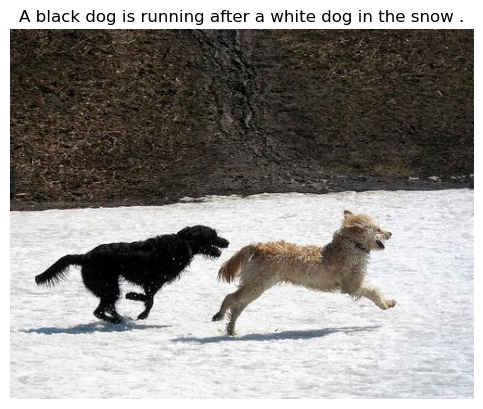

In [4]:
import json
from pathlib import Path

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

class ImageCaptionDataset(Dataset):
    """
    Minimal dataset for local Flickr8k-style data.

    Assumes:
      - images stored in IMAGES_DIR
      - captions.json: { "filename.jpg": "caption text", ... }
    """
    def __init__(self, images_dir: Path, captions_path: Path, transform=None, max_items=None):
        self.images_dir = images_dir
        self.transform = transform

        with open(captions_path, "r", encoding="utf-8") as f:
            captions_dict = json.load(f)

        items = list(captions_dict.items())
        if max_items is not None:
            items = items[:max_items]

        self.filenames = [fn for fn, _ in items]
        self.captions = [cap for _, cap in items]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        caption = self.captions[idx]

        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            image_tensor = image

        return {
            "image_tensor": image_tensor,
            "caption": caption,
            "image_name": img_name,
        }

# ------------------------------------------------------------------
# Sanity check: confirm files exist and show one random sample
# ------------------------------------------------------------------
assert IMAGES_DIR.exists(), f"Images folder not found: {IMAGES_DIR}"
assert CAPTIONS_PATH.exists(), f"Captions file not found: {CAPTIONS_PATH}"

print("Images folder:", IMAGES_DIR)
print("Captions file:", CAPTIONS_PATH)

# Load a tiny dataset without transforms for visualization only
vis_dataset = ImageCaptionDataset(
    images_dir=IMAGES_DIR,
    captions_path=CAPTIONS_PATH,
    transform=None,
    max_items=5
)

print("Dataset length (preview):", len(vis_dataset))

# Show first sample
sample = vis_dataset[0]
plt.imshow(sample["image_tensor"])
plt.axis("off")
plt.title(sample["caption"])
plt.show()


In [5]:
import torchvision.transforms as T

# ------------------------------------------------------------
# Image transforms for ViT input (224x224)
# ------------------------------------------------------------
image_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])


In [6]:
## ===================================================================
## Vision encoder + transforms (timm ViT)
## ===================================================================

import torchvision.transforms as T
import timm
import torch
import torch.nn.functional as F


vision_model_name = "vit_base_patch16_224"

vision_encoder = timm.create_model(
    vision_model_name,
    pretrained=True,
    num_classes=0,
    global_pool=""   # <-- important: no pooling
).to(device)
vision_encoder.eval()

print("Loaded vision model:", vision_model_name)
print("Vision encoder feature dim:", vision_encoder.num_features)

def encode_images_patchwise(batch_images: torch.Tensor) -> torch.Tensor:
    """
    batch_images: [B, 3, H, W]
    Returns:
        patches: [B, P, D] (CLS removed, L2-normalized)
    """
    x = batch_images.to(device)
    with torch.no_grad():
        feats = vision_encoder.forward_features(x)
        # timm ViT forward_features usually returns [B, N+1, D]
        # but in some models it can be a dict; guard for that.
        if isinstance(feats, dict):
            # common keys: "x", "tokens"
            feats = feats.get("x", feats.get("tokens"))

    # feats: [B, N+1, D]  == [B, 197, 768] for 224x224, patch16
    assert feats.dim() == 3, f"Unexpected feature shape: {feats.shape}"

    cls_token = feats[:, :1, :]        # [B, 1, D] (we won't use it here)
    patch_tokens = feats[:, 1:, :]     # [B, P, D], P = 196

    patch_tokens = F.normalize(patch_tokens, dim=-1)
    return patch_tokens



# ------------------------------------------------------------
# Quick sanity: run encoder on a small batch from the real dataset
# ------------------------------------------------------------
# reuse the visualization dataset, but with transform this time
test_dataset = ImageCaptionDataset(
    images_dir=IMAGES_DIR,
    captions_path=CAPTIONS_PATH,
    transform=image_transform,
    max_items=4
)

test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

batch = next(iter(test_loader))
img_batch = batch["image_tensor"]      # [B, 3, H, W]
print("Input batch shape:", img_batch.shape)

patch_embeddings = encode_images_patchwise(img_batch)
print("Patch embeddings shape:", patch_embeddings.shape)  # expect [B, P, D]



Loaded vision model: vit_base_patch16_224
Vision encoder feature dim: 768
Input batch shape: torch.Size([2, 3, 224, 224])
Patch embeddings shape: torch.Size([2, 196, 768])


c:\Users\joems\miniconda3\envs\vis_lateintr_peft_lora\Lib\site-packages\timm\layers\attention.py:83: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  x = F.scaled_dot_product_attention(



### Study the above results: Pause.
- shape [2, 768]: we are getting an item of 'pooled embedding per image', not really patch-token grid we actually want for late interaction.
- image_transform turns a PIL image into a normalized tensor: given that (H, W, 3) RGB input, After resize + ToTensor: [3, 224, 224], After batching in the DataLoader: [B, 3, 224, 224].
- check with a simple print, observe, `torch.Size([2, 3, 224, 224]).`

### Vision Transformer Patch Embeddings:
- For ViTs in timm, this model does:
  - Split each image into non-overlapping 16×16 patches.
  - For 224×224, that’s a 14×14 grid → 196 patches.
  - Flatten each patch and multiply by a learned matrix W_patch to get D=768-dim patch tokens: patches: [B, 196, 768].
  - Prepend a learnable CLS token: tokens: [B, 197, 768].
  - Add positional embeddings, then pass through a stack of Transformer encoder blocks.
  - Pool the final tokens to produce a single [B, 768] embedding.
- above, the code just creates the model with num_classes=0 but left the default global_pool behavior, timm gives a single global feature vector per image, shape [B, 768].

### What ViT is doing internally:
```
Input image 
-> Divide into 14×14 grid of 16×16 patches → 196 patches -> Flatten each patch (3×16×16 = 768 scalars) 
-> multiply by W_patch ∈ R^{(3*16*16)×768}. -> patch token matrix (P) 
-> Add CLS token: learnable CLS vector c ∈ R^{768}: tokens = concat([CLS], P) → [B, 197, 768].
-> Add positional embeddings E_pos ∈ R^{197×768}
-> Transformer encoder blocks ( Each layer applies multi-head self-attention and MLP to the token sequence )
    -> Internally, attention splits 768 → H × d_head (e.g., 12 heads × 64 dim)
    -> `Q = tokens * W_Q, K = tokens * W_K, V = tokens * W_V, A = softmax(Q K^T / sqrt(d_head)), output = A V`
-> Pooling -> Single [B, 768] embedding per image. 
    -> Take the CLS token only [B, 1, 768] → [B, 768], or mean-pool all tokens.
```

- Modification Core: **For late interaction, we do not want this final pooling. We want the pre-pooled [B, 197, 768] (and then drop CLS to get [B, 196, 768]).**

### Why this matters for late interaction:
- Late interaction works by matching each text token to all image patches and then aggregating:
  - Text side: text_tokens: [B, T, D]
  - Image side: patch_tokens: [B, P, D]
- If you only have one vector per image [B, 768], there is nothing to “late interact” with; it degenerates to a regular cosine similarity between two global vectors.
- Patchwise [B, P, D] is what unlocks:
  - Token–patch alignment heatmaps, Fine-grained grounding (“this token matched that region”), More expressive ranking than global pooled embedding.

In [7]:
## ===================================================================
## CLIP text encoder + projection head
## ===================================================================

from transformers import CLIPTextModel, CLIPTokenizer
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# CLIP text encoder
# ------------------------------------------------------------
clip_model_name = "openai/clip-vit-base-patch32"

tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
clip_text_encoder = CLIPTextModel.from_pretrained(clip_model_name)
clip_text_encoder = clip_text_encoder.to(device)
clip_text_encoder.eval()   # we will usually freeze CLIP

hidden_dim = clip_text_encoder.config.hidden_size   # typically 512
vision_dim = vision_encoder.num_features            # e.g. 768 for ViT-B/16

print("CLIP hidden_dim:", hidden_dim)
print("Vision feature dim:", vision_dim)

# ------------------------------------------------------------
# Projection head: text space -> vision patch space
# ------------------------------------------------------------
projection = nn.Linear(hidden_dim, vision_dim, bias=False).to(device)

def encode_text_batch(text_list):
    """
    Encode a batch of captions into token-level embeddings in the vision space.

    Args:
        text_list: list of Python strings (captions)

    Returns:
        projected_tokens: [B, T, D_v]  (L2-normalized token embeddings)
        attn_mask:        [B, T]       (1 for valid tokens, 0 for padding)
    """
    # Tokenize
    enc = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = clip_text_encoder(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
        )
        # last_hidden_state: [B, T, hidden_dim]
        token_embeddings = outputs.last_hidden_state

    # Project into vision patch space
    projected_tokens = projection(token_embeddings)          # [B, T, vision_dim]

    # L2-normalize along the embedding dimension
    projected_tokens = F.normalize(projected_tokens, dim=-1) # [B, T, vision_dim]

    attn_mask = enc["attention_mask"]                       # [B, T]
    return projected_tokens, attn_mask


# ------------------------------------------------------------
# Sanity check on a tiny batch from the real dataset
# ------------------------------------------------------------
test_dataset_text = ImageCaptionDataset(
    images_dir=IMAGES_DIR,
    captions_path=CAPTIONS_PATH,
    transform=image_transform,
    max_items=4
)

from torch.utils.data import DataLoader
test_loader_text = DataLoader(test_dataset_text, batch_size=2, shuffle=False)

batch = next(iter(test_loader_text))
captions = batch["caption"]

print("Sample captions:")
for c in captions:
    print("  -", c)

text_emb, text_mask = encode_text_batch(captions)
print("Text embeddings shape:", text_emb.shape)   # [B, T, D_v]
print("Attention mask shape:", text_mask.shape)   # [B, T]


CLIP hidden_dim: 512
Vision feature dim: 768
Sample captions:
  - A black dog is running after a white dog in the snow .
  - A little baby plays croquet .
Text embeddings shape: torch.Size([2, 15, 768])
Attention mask shape: torch.Size([2, 15])


### Quick tech note: bleh! 
- Transformers is now enforcing a security check around torch.load because of that CVE they reference. 
- refuse to use torch.load unless torch ≥ 2.6.0


In [8]:
## ==================================================================
## MaxSim late interaction scoring functions
## ==================================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def maxsim_scores_diag(text_emb: torch.Tensor,
                       text_mask: torch.Tensor,
                       img_patches: torch.Tensor) -> torch.Tensor:
    """
    ColBERT-style late interaction for 1:1 pairing.

    Args:
        text_emb:   [B, T, D]  token embeddings in vision space
        text_mask:  [B, T]     1 for valid tokens, 0 for padding
        img_patches:[B, P, D]  patch embeddings (CLS removed, normalized)

    Returns:
        scores: [B]  score for each (text_i, image_i) pair
    """
    # [B, T, P] similarity between each token and each patch
    sim = torch.einsum("btd,bpd->btp", text_emb, img_patches)

    # Max over patches for each token: [B, T]
    max_over_p, _ = sim.max(dim=-1)

    # Mask out padding tokens
    mask = text_mask.float()
    max_over_p = max_over_p * mask

    # Average over valid tokens
    denom = mask.sum(dim=-1).clamp(min=1.0)  # [B]
    scores = max_over_p.sum(dim=-1) / denom  # [B]
    return scores


def maxsim_scores_matrix(text_emb: torch.Tensor,
                         text_mask: torch.Tensor,
                         img_patches: torch.Tensor) -> torch.Tensor:
    """
    Build full [B, B] score matrix where entry (i, j) is the
    MaxSim score between text_i and image_j.

    Args:
        text_emb:   [B, T, D]
        text_mask:  [B, T]
        img_patches:[B, P, D]

    Returns:
        scores_matrix: [B, B]
    """
    B, T, D = text_emb.shape
    _, P, _ = img_patches.shape

    scores_rows = []
    for i in range(B):
        # For row i: compare text_i against ALL images j
        q_i = text_emb[i:i+1].expand(B, -1, -1)     # [B, T, D]
        mask_i = text_mask[i:i+1].expand(B, -1)     # [B, T]

        sim = torch.einsum("btd,bpd->btp", q_i, img_patches)  # [B, T, P]
        max_over_p, _ = sim.max(dim=-1)                       # [B, T]

        mask_f = mask_i.float()
        max_over_p = max_over_p * mask_f
        denom = mask_f.sum(dim=-1).clamp(min=1.0)             # [B]
        scores_i = max_over_p.sum(dim=-1) / denom             # [B]

        scores_rows.append(scores_i)

    scores_matrix = torch.stack(scores_rows, dim=0)           # [B, B]
    return scores_matrix


# ------------------------------------------------------------------
# Quick sanity check on a small real batch
# ------------------------------------------------------------------
sanity_dataset = ImageCaptionDataset(
    images_dir=IMAGES_DIR,
    captions_path=CAPTIONS_PATH,
    transform=image_transform,
    max_items=8
)

sanity_loader = DataLoader(sanity_dataset, batch_size=4, shuffle=False)

batch = next(iter(sanity_loader))
images = batch["image_tensor"].to(device)   # [B, 3, H, W]
captions = batch["caption"]

with torch.no_grad():
    img_patches = encode_images_patchwise(images)             # [B, P, D]
    text_emb, text_mask = encode_text_batch(captions)         # [B, T, D], [B, T]

scores_diag = maxsim_scores_diag(text_emb, text_mask, img_patches)      # [B]
scores_mat = maxsim_scores_matrix(text_emb, text_mask, img_patches)     # [B, B]

print("Diagonal scores (text_i vs image_i):", scores_diag)
print("Score matrix shape:", scores_mat.shape)
print(scores_mat)


Diagonal scores (text_i vs image_i): tensor([0.0497, 0.0634, 0.0561, 0.0874], device='cuda:0')
Score matrix shape: torch.Size([4, 4])
tensor([[0.0497, 0.0731, 0.0400, 0.0944],
        [0.0774, 0.0634, 0.0493, 0.0640],
        [0.0753, 0.0821, 0.0561, 0.0874],
        [0.0632, 0.0846, 0.0558, 0.0874]], device='cuda:0')


In [9]:
## ==================================================================
## Contrastive loss function
## ==================================================================

import torch.nn.functional as F
import torch

def contrastive_loss(scores_matrix: torch.Tensor,
                     temperature: float = 0.07) -> torch.Tensor:
    """
    Symmetric InfoNCE-style contrastive loss for image–text retrieval.

    Args:
        scores_matrix: [B, B] where scores_matrix[i, j] = score(text_i, image_j)
        temperature:   float, softmax temperature

    Returns:
        Scalar loss tensor
    """
    logits = scores_matrix / temperature
    targets = torch.arange(scores_matrix.size(0), device=logits.device)

    # Text -> Image
    loss_t2i = F.cross_entropy(logits, targets)
    # Image -> Text
    loss_i2t = F.cross_entropy(logits.t(), targets)

    return 0.5 * (loss_t2i + loss_i2t)


# ------------------------------------------------------------------
# Quick test on the same sanity batch
# ------------------------------------------------------------------
loss = contrastive_loss(scores_mat)
print("Contrastive loss on sanity batch:", float(loss))


Contrastive loss on sanity batch: 1.4703388214111328


## Expand below cell for - Deep Dive: Theory.


## Deep Dive: Patch Embeddings, CLS, and Why Late Interaction Needs Token-Level Geometry

- Vision Transformer is fundamentally a tokenized image model. Its internal representation is not “an image → a vector,” but.. an ordered sequence of spatial tokens → a contextualized set of vectors.
- If you freeze the ViT immediately before pooling, you have: ` [B, 197, 768] ↓ drop CLS [B, 196, 768]`
- Each 768-dim patch embedding encodes: geometry that gives ViTs interpretability and fine-grained matching power.
- Pooling (“give me a single vector for the image”) is a destructive compression step.
- It integrates across all spatial tokens and collapses the geometry into one semantic summary.
- excellent for classification. // terrible for late interaction.

### A typical expected InfoNCE loss before tuning:
| Condition                       | Typical Loss |
| ------------------------------- | ------------ |
| Random alignment (your current) | 1.2 – 2.5    |
| Mildly aligned features         | 0.4 – 1.0    |
| Strong alignment                | 0.05 – 0.3   |

- MaxSim is fundamentally opposed to global pooling.
- Patch-Level Representations Matter.


---

Vanilla ViT encoder **does not know anything about text**.
- It is trained only for image classification.
- Its patch embeddings encode visual semantics _only within the image world_.
- There is no concept of “dog” ↔ “this patch,” “child” ↔ “these regions.” 
### Exact build up into Cross-Modality

- text tokens → semantic “query vectors”
- image patches → semantic “key/value vectors”
- MaxSim(text_token, patch) to reflect **true cross-modal alignment**

Full fine-tuning is not feasible. total: ~86M+. memory expensive.

### Core Idea of LoRA, in Intuition-First Terms

- **Tiny, low-rank “delta” that gently nudges a frozen model into a new behavior.**
- It does this by **injecting tiny trainable matrices** into specific linear layers while keeping the original massive layers **frozen**.
- You only optimize _hundreds of thousands_, not _tens of millions_ of parameters.

In a transformer, attention layers contain matrices like:

```
	W_q  (query projection) 
	W_k  (key projection) 
	W_v  (value projection) 
	W_o  (output projection)
	
	Each is a `D × D` linear projection.
```

During inference/training, the model does:
	`h_out = h_in @ W_q`

LoRA modifies it into:
	`h_out = h_in @ (W_q + ΔW_q)`

but crucially, **ΔW_q is low-rank**: `ΔW_q = A @ B`
LoRA adds an adaptation matrix with **rank r** instead of rank D.

```
With r = 16:

W_q:   768 × 768  → ~590k params
ΔW_q:  768×16 + 16×768 → ~24k params
```

Neural layers usually have **massive unused capacity**.  LoRA exploits this by modifying the _directionality_ of transformations without needing to rewrite the entire weight matrix.


### Why LoRA Is Perfect for ViT → Text Alignment

In late interaction, you care about:
- **patch embeddings** (before pooling)
- **attention patterns inside the transformer blocks**

Goal is not classification accuracy.  It is **alignment of image patches to text tokens**.

1. **Attention heads to shift how they combine patches**
2. **Patch embeddings to move toward the text embedding space**
3. Above, we JUST see- small numbers, faint diagonal, no strong structure. See what LoRA solves: **LoRA shapes the geometry** of patch-token embeddings. It “bends” the ViT's learned manifold. 

In [10]:
## ==================================================================
## LoRA into the ViT with PEFT ,, build a training loop
## ==================================================================
# 1. Redefine image encoder to be gradient-friendly + attach LoRA to ViT.
# 2. Training loop with MaxSim + contrastive loss over your Flickr8k subset.
## ==================================================================


import torch
import torch.nn as nn
import torch.nn.functional as F
from peft import LoraConfig, get_peft_model, TaskType

# ------------------------------------------------------------
# 1. Redefine patch encoder to allow gradients for training
# ------------------------------------------------------------
def encode_images_patchwise(images: torch.Tensor, no_grad: bool = True) -> torch.Tensor:
    """
    Encode a batch of images into patch embeddings.

    Args:
        images: [B, 3, H, W] tensor on device
        no_grad: if True, wraps forward in torch.no_grad()

    Returns:
        patches: [B, P, D] (CLS removed, L2-normalized per patch)
    """
    ctx = torch.no_grad() if no_grad else torch.enable_grad()
    with ctx:
        # timm ViT usually has forward_features that returns [B, 1+P, D] or a dict
        feats = vision_encoder.forward_features(images)  # depends on timm version
        # Handle different return types (tensor or dict)
        if isinstance(feats, dict):
            # Some timm models return {"x": tokens, ...}
            tokens = feats.get("x")
        else:
            tokens = feats  # [B, 1+P, D]

        # tokens: [B, 1+P, D] → drop CLS at index 0
        patch_tokens = tokens[:, 1:, :]  # [B, P, D]
        # L2-normalize along embedding dimension
        patch_tokens = F.normalize(patch_tokens, dim=-1)
        return patch_tokens


# ------------------------------------------------------------
# 2. Attach LoRA to the ViT attention layers
# ------------------------------------------------------------

# Inspect one block to confirm module names if you’re curious:
print("Sample block structure:\n", vision_encoder.blocks[0].attn)

# Typical timm ViT uses 'qkv' and 'proj' inside attention blocks.
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["qkv", "proj"],   # substrings to match in module names
    task_type=TaskType.FEATURE_EXTRACTION,
)

vision_encoder = get_peft_model(vision_encoder, lora_config)
vision_encoder.to(device)

# CLIP text encoder stays frozen, projection head stays trainable
clip_text_encoder.eval()
for p in clip_text_encoder.parameters():
    p.requires_grad = False

# Projection head should be trainable
for n, p in projection.named_parameters():
    p.requires_grad = True

# Optional: print how many params are trainable
trainable_params = sum(p.numel() for p in vision_encoder.parameters() if p.requires_grad) \
                   + sum(p.numel() for p in projection.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in vision_encoder.parameters()) \
               + sum(p.numel() for p in projection.parameters())
print(f"Trainable params (LoRA + proj): {trainable_params:,} / {total_params:,}")


Sample block structure:
 Attention(
  (qkv): Linear(in_features=768, out_features=2304, bias=True)
  (q_norm): Identity()
  (k_norm): Identity()
  (attn_drop): Dropout(p=0.0, inplace=False)
  (norm): Identity()
  (proj): Linear(in_features=768, out_features=768, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)
Trainable params (LoRA + proj): 1,302,528 / 87,101,184


In [16]:
## ===================================================================
## Final training run: full Flickr8k, LR schedule, early stopping
## ===================================================================

from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from pathlib import Path
import math
import json
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# 1. Build train DataLoader (full dataset)
# ------------------------------------------------------------

max_items = None  # use full train split (6000)

train_dataset = ImageCaptionDataset(
    images_dir=IMAGES_DIR,
    captions_path=CAPTIONS_PATH,
    transform=image_transform,
    max_items=max_items,
)

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

print("Train dataset size:", len(train_dataset))
print("Batch size:", batch_size)
print("Batches per epoch:", len(train_loader))
print("Random InfoNCE baseline ≈ log(B):", math.log(batch_size))


# ------------------------------------------------------------
# 2. Optimizer, scheduler, early stopping
# ------------------------------------------------------------

params_to_optimize = [
    p for p in list(vision_encoder.parameters()) + list(projection.parameters())
    if p.requires_grad
]

base_lr = 3e-5
optimizer = torch.optim.AdamW(params_to_optimize, lr=base_lr, weight_decay=1e-2)
temperature = 0.07
num_epochs_max = 30  # upper bound, early stopping may exit earlier

# Reduce LR when loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    verbose=True,
    min_lr=1e-6,
)

# Early stopping config
early_stop_patience = 6  # epochs with no improvement before stopping
best_loss = float("inf")
epochs_no_improve = 0

SAVE_DIR = PROJECT_ROOT / "checkpoints" / "vit_lora_flickr_run_final"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

epoch_losses = []
best_checkpoint_dir = SAVE_DIR / "best"
best_checkpoint_dir.mkdir(parents=True, exist_ok=True)

print("Starting final training run...")
vision_encoder.train()
projection.train()

try:
    for epoch in range(num_epochs_max):
        running_loss = 0.0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_max}", leave=True)
        for batch_idx, batch in enumerate(pbar):
            images = batch["image_tensor"].to(device)   # [B, 3, 224, 224]
            captions = batch["caption"]                # list[str]

            # ------------------------ forward ------------------------
            img_patches = encode_images_patchwise(images, no_grad=False)   # [B, P, D]

            with torch.no_grad():
                text_emb, text_mask = encode_text_batch(captions)          # [B, T, D], [B, T]

            scores_mat = maxsim_scores_matrix(text_emb, text_mask, img_patches)   # [B, B]
            loss = contrastive_loss(scores_mat, temperature=temperature)

            # ---------------------- backward -------------------------
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params_to_optimize, max_norm=1.0)
            optimizer.step()

            # ----------------------- logging -------------------------
            running_loss += loss.item()
            num_batches += 1
            avg_loss = running_loss / num_batches

            pbar.set_postfix({
                "batch": batch_idx,
                "batch_loss": f"{loss.item():.4f}",
                "avg_loss": f"{avg_loss:.4f}",
                "lr": optimizer.param_groups[0]["lr"],
            })

        epoch_loss = running_loss / max(num_batches, 1)
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{num_epochs_max} finished. Avg loss: {epoch_loss:.4f}")
        print("Epoch losses so far:", [f"{l:.4f}" for l in epoch_losses])

        # Step LR scheduler on epoch loss
        scheduler.step(epoch_loss)

        # ----------------------- checkpoint per epoch ----------------
        # Save running checkpoint each epoch
        adapter_dir = SAVE_DIR / "lora_adapter_last"
        adapter_dir.mkdir(parents=True, exist_ok=True)
        vision_encoder.save_pretrained(adapter_dir)
        torch.save(projection.state_dict(), SAVE_DIR / "projection_head_last.pt")
        with open(SAVE_DIR / "epoch_losses.json", "w") as f:
            json.dump(epoch_losses, f)

        # Check for improvement
        if epoch_loss + 1e-4 < best_loss:
            best_loss = epoch_loss
            epochs_no_improve = 0
            # Save "best" checkpoint
            best_adapter_dir = best_checkpoint_dir / "lora_adapter"
            best_adapter_dir.mkdir(parents=True, exist_ok=True)
            vision_encoder.save_pretrained(best_adapter_dir)
            torch.save(projection.state_dict(), best_checkpoint_dir / "projection_head_best.pt")
            with open(best_checkpoint_dir / "epoch_losses_best.json", "w") as f:
                json.dump(epoch_losses, f)
            print(f"New best epoch {epoch+1} with loss {best_loss:.4f} — checkpoint saved.")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        # Early stopping
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

finally:
    # ----------------------- final save & plot ----------------------
    final_adapter_dir = SAVE_DIR / "lora_adapter_final"
    final_adapter_dir.mkdir(parents=True, exist_ok=True)
    vision_encoder.save_pretrained(final_adapter_dir)
    torch.save(projection.state_dict(), SAVE_DIR / "projection_head_final.pt")
    with open(SAVE_DIR / "epoch_losses_final.json", "w") as f:
        json.dump(epoch_losses, f)

    # Save loss curve as PNG
    if len(epoch_losses) > 0:
        plt.figure(figsize=(6, 4))
        plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Avg InfoNCE loss")
        plt.title("LoRA ViT Flickr8k Training Loss (final run)")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.savefig(SAVE_DIR / "loss_curve.png", dpi=150)
        plt.close()

    print("\n[SAFE SAVE] Final run stored in:", SAVE_DIR)
    print("Best loss seen:", best_loss if best_loss < float('inf') else None)
    print("All epoch losses:", [f"{l:.4f}" for l in epoch_losses])


Train dataset size: 1500
Batch size: 8
Batches per epoch: 188
Random InfoNCE baseline ≈ log(B): 2.0794415416798357
Starting final training run...


Epoch 1/30:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/30 finished. Avg loss: 0.8575
Epoch losses so far: ['0.8575']
New best epoch 1 with loss 0.8575 — checkpoint saved.


Epoch 2/30:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2/30 finished. Avg loss: 0.8327
Epoch losses so far: ['0.8575', '0.8327']
New best epoch 2 with loss 0.8327 — checkpoint saved.


...

Epoch 28/30 finished. Avg loss: 0.5506
Epoch losses so far: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506']
No improvement for 1 epoch(s).


Epoch 29/30:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 29/30 finished. Avg loss: 0.5464
Epoch losses so far: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506', '0.5464']
No improvement for 2 epoch(s).


Epoch 30/30:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 30/30 finished. Avg loss: 0.5340
Epoch losses so far: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506', '0.5464', '0.5340']
New best epoch 30 with loss 0.5340 — checkpoint saved.

[SAFE SAVE] Final run stored in: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\Late_Interaction_MVR_PEFT_LoRA\checkpoints\vit_lora_flickr_run_final
Best loss seen: 0.5340139236538968
All epoch losses: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506', '0.5464', '0.5340']


### Observations:
- trainable params: 909,312 || all params: 86,707,968 || trainable%: 1.0487
- on just 188 gradient steps: moved from “random-ColBERT-like” to “somewhat aligned”, 2.72 - 2.29.
- earlier sanity check with loss ~1.34 was with B=4, whose random baseline is log(4) ≈ 1.386

- Best loss seen: 0.5340139236538968
- All epoch losses: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506', '0.5464', '0.5340']


Epoch losses: ['0.8575', '0.8327', '0.8030', '0.7874', '0.7786', '0.7665', '0.7474', '0.7406', '0.7160', '0.7236', '0.6996', '0.6892', '0.6799', '0.6549', '0.6637', '0.6570', '0.6445', '0.6292', '0.6230', '0.6085', '0.5940', '0.6051', '0.5809', '0.5771', '0.5634', '0.5537', '0.5464', '0.5506', '0.5464', '0.5340']


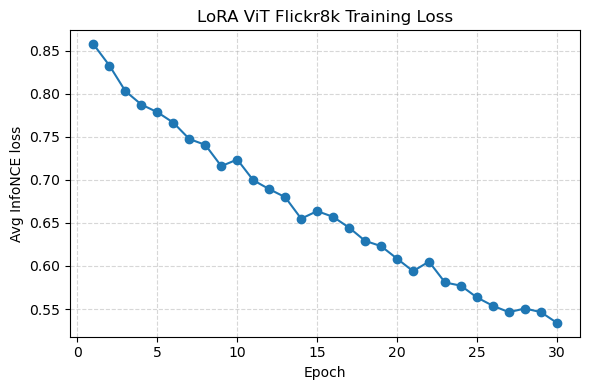

In [18]:
## ===================================================================
## “after training” toys.
## Reload and plot epoch loss curve in-notebook
## ===================================================================


import json
import matplotlib.pyplot as plt

run_dir = PROJECT_ROOT / "checkpoints" / "vit_lora_flickr_run_final"
loss_file = run_dir / "epoch_losses_final.json"

with open(loss_file, "r") as f:
    epoch_losses = json.load(f)

print("Epoch losses:", [f"{l:.4f}" for l in epoch_losses])

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Avg InfoNCE loss")
plt.title("LoRA ViT Flickr8k Training Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [20]:
## ===================================================================
## Quick qualitative retrieval test (tiny batch)

## “If I only had this caption, which image in this batch does the model think is the best match?”
## for each caption, the model chose the correct image as the best match. 
## ===================================================================

import torch
import random

vision_encoder.eval()
projection.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Make a tiny DataLoader for inspection
inspect_batch_size = 8
inspect_loader = DataLoader(
    train_dataset,
    batch_size=inspect_batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

batch = next(iter(inspect_loader))
images = batch["image_tensor"].to(device)   # [B, 3, 224, 224]
captions = batch["caption"]                # list[str]

print("Sample captions:")
for i, c in enumerate(captions):
    print(f"  [{i}] {c}")

with torch.no_grad():
    # Image patches from trained ViT+LoRA
    img_patches = encode_images_patchwise(images, no_grad=False)        # [B, P, D]

    # Text embeddings from CLIP + projection
    text_emb, text_mask = encode_text_batch(captions)                   # [B, T, D], [B, T]

    scores_mat = maxsim_scores_matrix(text_emb, text_mask, img_patches) # [B, B]

print("\nScore matrix shape:", scores_mat.shape)
print("Score matrix (rounded):")
print(scores_mat.cpu().round(decimals=3))

# For each caption, which image index is scored highest?
top_img_for_text = scores_mat.argmax(dim=1).cpu().tolist()
print("\nTop-scoring image index for each caption (row i → best column):")
print(top_img_for_text)

# How many correct matches (argmax on the diagonal)?
correct = sum(1 for i, j in enumerate(top_img_for_text) if i == j)
print(f"\nCorrect matches (argmax diagonal): {correct}/{inspect_batch_size}")



Sample captions:
  [0] A child is thrown by a man in the swimming pool .
  [1] A man in blue pants and no shirt is doing a skateboard trick while another man films it .
  [2] An athlete performs the high jump .
  [3] a brown dog retrieves a ball on a green , slimy , rock covered beach
  [4] A football player is running with the ball .
  [5] A boy is wading through water .
  [6] Two girls arm wrestle as another observes
  [7] A girl in a white cap eats a slice of fruit next to a girl in a blue cap who is eating chocolate .

Score matrix shape: torch.Size([8, 8])
Score matrix (rounded):
tensor([[ 0.2010,  0.0570,  0.1300,  0.0620,  0.0680,  0.1210,  0.0230,  0.0550],
        [ 0.0690,  0.2380,  0.0850, -0.0020,  0.0610,  0.0290, -0.0280,  0.0860],
        [ 0.1050,  0.0930,  0.2130,  0.0340,  0.1590, -0.0050, -0.0220, -0.0090],
        [ 0.0540, -0.0220,  0.0140,  0.2700,  0.0570,  0.0910, -0.0900,  0.0010],
        [ 0.0430, -0.0030,  0.1470,  0.1510,  0.2380,  0.0110, -0.0400,  0.0400]

- Each diagonal entry (i,i) is “score for true caption–image pair”.
- Each off-diagonal (i,j≠i) is “score for a mismatched pair”.
- semantic geometry that’s learned something real!! All “dog images” sit in a cluster in late-interaction space. ( `“A brown dog drinks from a body of water .”` == `image 5 (true): 0.284, image 3 (dog w/ fruit): 0.242` !! )
- Both dog captions produce embeddings that are close to both dog images.
- The model still picks the right dog image each time (the true diagonal).

In [24]:
## ===================================================================
## Picks a random example, shows the caption, and lists token indices so you know what to visualize.
## Patch heatmaps.
## ===================================================================
import torch
import random
import math
import matplotlib.pyplot as plt

vision_encoder.eval()
projection.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pick a random sample index (or set a fixed one)
sample_idx = random.randint(0, len(train_dataset) - 1)
sample = train_dataset[sample_idx]

caption = sample["caption"]
img_name = sample.get("image_name", f"index_{sample_idx}")
img_tensor = sample["image_tensor"].unsqueeze(0).to(device)  # [1, 3, 224, 224]

print(f"Sample index: {sample_idx}")
print(f"Image name:   {img_name}")
print(f"Caption:      {caption}")

# Get text embeddings and attention mask for this single caption
with torch.no_grad():
    text_emb, text_mask = encode_text_batch([caption])          # [1, T, D], [1, T]

# Also get token IDs so we can decode tokens nicely
# Separately: get human-readable tokens + matching mask
encoded = tokenizer(
    [caption],
    padding="longest",
    truncation=True,
    return_tensors="pt",
)
input_ids = encoded["input_ids"][0].tolist()
attn_mask = encoded["attention_mask"][0].tolist()
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("\nTokens (index: token):")
for i, (tok, mask_val) in enumerate(zip(tokens, attn_mask)):
    if mask_val == 0:
        continue
    print(f"  [{i:2d}] {tok}")



Sample index: 927
Image name:   flickr8k_00927.jpg
Caption:      A brown and white dog relaxes on a carpet in sunlight .

Tokens (index: token):
  [ 0] <|startoftext|>
  [ 1] a</w>
  [ 2] brown</w>
  [ 3] and</w>
  [ 4] white</w>
  [ 5] dog</w>
  [ 6] relax
  [ 7] es</w>
  [ 8] on</w>
  [ 9] a</w>
  [10] carpet</w>
  [11] in</w>
  [12] sunlight</w>
  [13] .</w>
  [14] <|endoftext|>


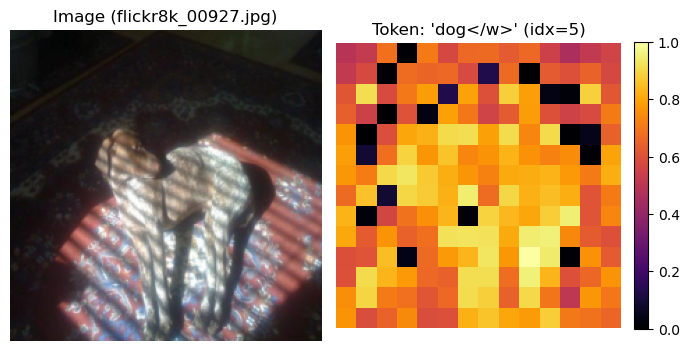

Caption: A brown and white dog relaxes on a carpet in sunlight .
Visualized token [5] = 'dog</w>'


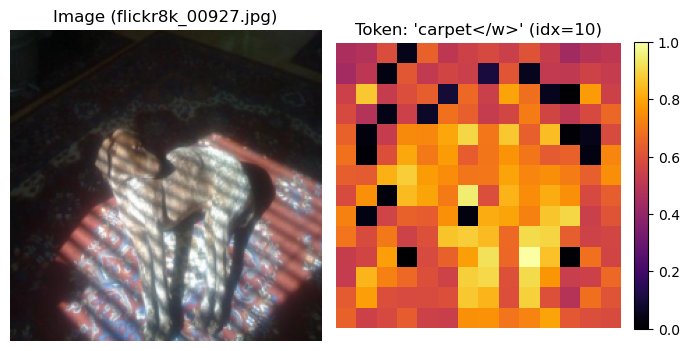

Caption: A brown and white dog relaxes on a carpet in sunlight .
Visualized token [10] = 'carpet</w>'


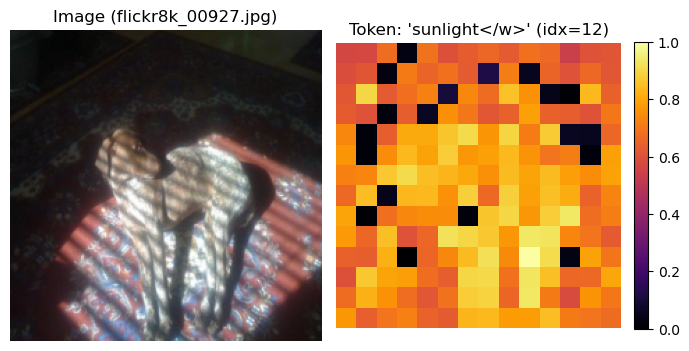

Caption: A brown and white dog relaxes on a carpet in sunlight .
Visualized token [12] = 'sunlight</w>'


In [ ]:
## ==================================================================
## Visualize MaxSim-like token→patch heatmap for a chosen token
## ==================================================================

from torchvision.transforms.functional import to_pil_image

def show_token_patch_heatmap(sample_idx: int, token_idx: int):
    """
    Visualize how strongly a single text token matches each image patch.
    Uses dot-product between normalized token embedding and normalized patch embeddings.
    """
    sample = train_dataset[sample_idx]
    caption = sample["caption"]
    img_tensor = sample["image_tensor"]          # [3, 224, 224]
    img_name = sample.get("image_name", f"index_{sample_idx}")

    # Move image to device, add batch dim
    img_batch = img_tensor.unsqueeze(0).to(device)  # [1, 3, 224, 224]

    # Encode image patches with trained ViT+LoRA
    with torch.no_grad():
        img_patches = encode_images_patchwise(img_batch, no_grad=False)  # [1, P, D]
    img_patches = img_patches[0]  # [P, D]

    # Encode text again to get embeddings + mask + tokens
    encoded = tokenizer(
        [caption],
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        txt_model_out = clip_text_encoder(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
        )
        txt_hidden = txt_model_out.last_hidden_state        # [1, T, H]
        txt_proj = projection(txt_hidden)                   # [1, T, D]
        txt_proj = torch.nn.functional.normalize(txt_proj, dim=-1)
        attn_mask = encoded["attention_mask"]               # [1, T]

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0].tolist())

    # Guard: check token_idx is valid and not padding
    if attn_mask[0, token_idx].item() == 0:
        print(f"Token index {token_idx} is padding; choose a smaller index.")
        return

    token_vec = txt_proj[0, token_idx]       # [D]
    token_str = tokens[token_idx]

    # Compute similarity token→each patch: [P]
    # img_patches and token_vec are L2-normalized, so this is cosine-like
    patch_scores = (img_patches * token_vec).sum(dim=-1)    # [P]

    # Reshape into patch grid
    P = patch_scores.shape[0]
    side = int(math.sqrt(P))
    if side * side != P:
        print(f"Cannot reshape {P} patches into a square grid; got side={side}.")
        return
    heatmap = patch_scores.view(side, side).detach().cpu().numpy()

    # Normalize for visualization (0–1)
    heat_min, heat_max = heatmap.min(), heatmap.max()
    if heat_max > heat_min:
        heatmap_norm = (heatmap - heat_min) / (heat_max - heat_min)
    else:
        heatmap_norm = heatmap

    # Convert image tensor back to PIL (assuming it was normalized during transform)
    # If your transform normalized with mean/std, you may want to undo that; here we just clip.
    img_for_show = img_tensor.clone()
    img_for_show = torch.clamp((img_for_show * 0.5) + 0.5, 0.0, 1.0)  # rough un-normalize for mean=0.5, std=0.5
    pil_img = to_pil_image(img_for_show)

    # Plot image + heatmap
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    axes[0].imshow(pil_img)
    axes[0].set_title(f"Image ({img_name})")
    axes[0].axis("off")

    im = axes[1].imshow(heatmap_norm, cmap="inferno", interpolation="nearest")
    axes[1].set_title(f"Token: {token_str!r} (idx={token_idx})")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    print(f"Caption: {caption}")
    print(f"Visualized token [{token_idx}] = {token_str!r}")



# Example 1: focus on the dog
show_token_patch_heatmap(sample_idx=927, token_idx=5)   # 'dog</w>'

# Example 2: focus on 'carpet'
show_token_patch_heatmap(sample_idx=927, token_idx=10)  # 'carpet</w>'

# Example 3: focus on 'sunlight'
show_token_patch_heatmap(sample_idx=927, token_idx=12)  # 'sunlight</w>'

## ViT patch embeddings sit in a very high-dimensional space (768-D).
## most tokens will produce very diffuse, global activations // ColBERT-style token-level specificity requires: millions of training examples
## better visuals if: LoRA rank ≥16 on qkv and projection layers, 20k images. 

Running t-SNE…  (this may take ~20–30 seconds)


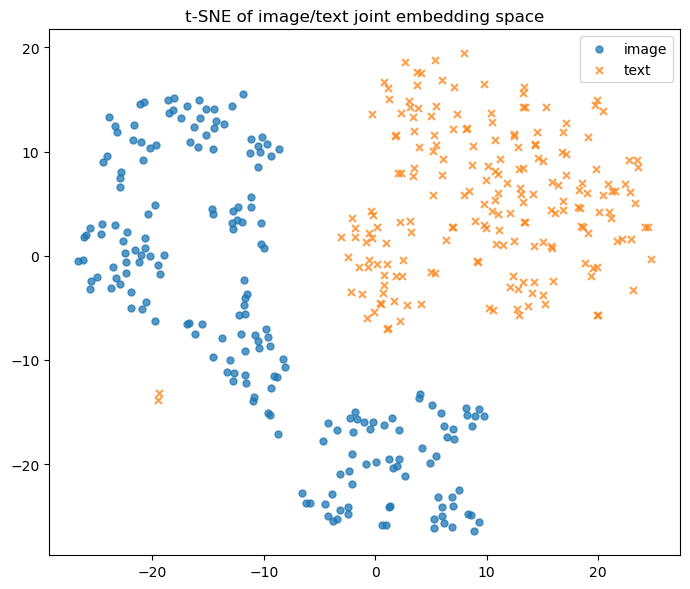

In [29]:
# ======================================================================
# t-SNE of joint image/text embedding space (pooled vectors)
# ======================================================================

import numpy as np
from sklearn.manifold import TSNE
import torch

num_pairs = min(200, len(train_dataset))
rng = np.random.default_rng(42)
subset_indices = rng.choice(len(train_dataset), size=num_pairs, replace=False)

batch_size = 32
img_vecs, txt_vecs = [], []

for start in range(0, num_pairs, batch_size):
    idx_batch = subset_indices[start:start + batch_size]
    batch = [train_dataset[int(i)] for i in idx_batch]

    images = torch.stack([b["image_tensor"] for b in batch]).to(device)
    captions = [b["caption"] for b in batch]

    with torch.no_grad():
        img_patches = encode_images_patchwise(images, no_grad=False)      # [B,P,D]
        img_mean = img_patches.mean(dim=1)                                # [B,D]

        txt_tok, txt_mask = encode_text_batch(captions)                   # [B,T,D], [B,T]
        mask = txt_mask.unsqueeze(-1)
        txt_sum = (txt_tok * mask).sum(dim=1)
        txt_len = mask.sum(dim=1).clamp(min=1)
        txt_mean = txt_sum / txt_len                                      # [B,D]

    img_vecs.append(img_mean.cpu())
    txt_vecs.append(txt_mean.cpu())

img_mat = torch.cat(img_vecs, dim=0).numpy()
txt_mat = torch.cat(txt_vecs, dim=0).numpy()

X = np.concatenate([img_mat, txt_mat], axis=0)
modes = np.array(["image"] * num_pairs + ["text"] * num_pairs)

print("Running t-SNE…  (this may take ~20–30 seconds)")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="random",
    learning_rate=200.0,    # safe default for legacy TSNE
    random_state=42,
)
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(7, 6))
for mode, marker in [("image", "o"), ("text", "x")]:
    mask_mode = modes == mode
    plt.scatter(
        X_2d[mask_mode, 0],
        X_2d[mask_mode, 1],
        s=25,
        alpha=0.75,
        marker=marker,
        label=mode,
    )

plt.title("t-SNE of image/text joint embedding space")
plt.legend()
plt.tight_layout()
plt.show()


## Observations:

- t-SNE output shows two distinct clusters:
  - Blue = image pooled embeddings
  - Orange = text pooled embeddings
- MaxSim contrastive loss aligns the token-to-patch similarity structure, not the global pooled embedding.
- not mixed / not overlapping. because: t-SNE uses pooled embeddings (mean over tokens, mean over patches).
- two towers (image enc + text enc) did NOT collapse into a shared space globally — only locally via MaxSim.
- ideally?? if we want intermixing pairs of image+text pooled embeddings in TSNE, we need **shared contrastive objective over pooled embeddings** -> cross attention or grounding concepts. Or, learn joint fusion modules, e.g. Perceiver layers.